## Time Series Model for sales

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error

import warnings
warnings.filterwarnings("ignore")

In [22]:
df = pd.read_excel("Forecasting Case- Study.xlsx", parse_dates=['Date',])

df.head()

,State,Date,Total,Category
0,Alabama,2019-01-12 00:00:00,109574036.0,Beverages
1,Arizona,2019-01-12 00:00:00,109101594.6,Beverages
2,Arkansas,2019-01-12 00:00:00,58049432.2,Beverages
3,California,2019-01-12 00:00:00,444766890.6,Beverages
4,Colorado,2019-01-12 00:00:00,89816716.3,Beverages


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8084 entries, 0 to 8083
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   State     8084 non-null   object 
 1   Date      8084 non-null   object 
 2   Total     8084 non-null   float64
 3   Category  8084 non-null   object 
dtypes: float64(1), object(3)
memory usage: 252.8+ KB


In [24]:
df.columns

Index(['State', 'Date', 'Total', 'Category'], dtype='object')

### Converting tha Date columns into Date format Data types

In [25]:
# Convert date column
df['Date'] = pd.to_datetime(df['Date'], format='mixed', dayfirst=True)

# Sort
df = df.sort_values(['State', 'Date'])

df.head()

,State,Date,Total,Category
0,Alabama,2019-01-12,109574036.0,Beverages
43,Alabama,2019-03-11,112189103.8,Beverages
86,Alabama,2019-06-10,129106730.4,Beverages
129,Alabama,2019-08-12,108083723.8,Beverages
172,Alabama,2019-10-11,110932912.8,Beverages


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8084 entries, 0 to 3224
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   State     8084 non-null   object        
 1   Date      8084 non-null   datetime64[ns]
 2   Total     8084 non-null   float64       
 3   Category  8084 non-null   object        
dtypes: datetime64[ns](1), float64(1), object(2)
memory usage: 315.8+ KB


In [27]:
df.isnull().sum()

State       0
Date        0
Total       0
Category    0
dtype: int64

In [28]:
df.drop_duplicates(inplace=True)

In [29]:
df.shape

(8084, 4)

### Rename the columns

In [30]:
df = df.rename(columns={
    'State': 'state',
    'Date': 'date',
    'Total': 'sales',
    'Category': 'category'
})

df.head()

,state,date,sales,category
0,Alabama,2019-01-12,109574036.0,Beverages
43,Alabama,2019-03-11,112189103.8,Beverages
86,Alabama,2019-06-10,129106730.4,Beverages
129,Alabama,2019-08-12,108083723.8,Beverages
172,Alabama,2019-10-11,110932912.8,Beverages


In [31]:
df.columns

Index(['state', 'date', 'sales', 'category'], dtype='object')

### Find the statewise data sales.

In [32]:
state_data = df.groupby(['state', 'date'])['sales'].sum().reset_index().sort_values(['state', 'date'])

state_data.head()

,state,date,sales
0,Alabama,2019-01-12,109574036.0
1,Alabama,2019-03-11,112189103.8
2,Alabama,2019-06-10,129106730.4
3,Alabama,2019-08-12,108083723.8
4,Alabama,2019-10-11,110932912.8


In [33]:
state_data.shape

(8084, 3)

In [34]:
df.shape

(8084, 4)

### Handle the missing Date

In [35]:
def fill_missing_dates(group):
    group = group.set_index('date').asfreq('D')
    group['sales'] = group['sales'].ffill()
    group['state'] = group['state'].iloc[0]
    return group.reset_index()

state_data = state_data.groupby('state').apply(fill_missing_dates).reset_index(drop=True)

In [36]:
state_data.shape

(76841, 3)

In [37]:
state_data.head()

,date,state,sales
0,2019-01-12,Alabama,109574036.0
1,2019-01-13,Alabama,109574036.0
2,2019-01-14,Alabama,109574036.0
3,2019-01-15,Alabama,109574036.0
4,2019-01-16,Alabama,109574036.0


In [38]:
state_data.drop_duplicates()

,date,state,sales
0,2019-01-12,Alabama,109574036.0
1,2019-01-13,Alabama,109574036.0
2,2019-01-14,Alabama,109574036.0
3,2019-01-15,Alabama,109574036.0
4,2019-01-16,Alabama,109574036.0
...,...,...,...
76836,2023-11-29,Wyoming,21188735.7
76837,2023-11-30,Wyoming,21188735.7
76838,2023-12-01,Wyoming,21188735.7
76839,2023-12-02,Wyoming,20510613.7


### Featuring Engineering Function

In [39]:
def create_features(df):

    df = df.copy()

    # Lag Features
    df['lag_1'] = df['sales'].shift(1)

    df['lag_7'] = df['sales'].shift(7)

    df['lag_30'] = df['sales'].shift(30)

    # Rolling Features
    df['rolling_mean_7'] = (
        df['sales']
        .shift(1)
        .rolling(7)
        .mean()
    )

    df['rolling_std_7'] = (
        df['sales']
        .shift(1)
        .rolling(7)
        .std()
    )

    # Date Features
    df['day_of_week'] = df['date'].dt.dayofweek

    df['month'] = df['date'].dt.month

    return df

### Apply Feature Engineering

In [40]:
state_data = (
    state_data.groupby('state')
    .apply(create_features)
    .dropna()
    .reset_index(drop=True)
)

state_data.head()

,date,state,sales,lag_1,lag_7,lag_30,rolling_mean_7,rolling_std_7,day_of_week,month
0,2019-02-11,Alabama,109574036.0,109574036.0,109574036.0,109574036.0,109574036.0,0.0,0,2
1,2019-02-12,Alabama,109574036.0,109574036.0,109574036.0,109574036.0,109574036.0,0.0,1,2
2,2019-02-13,Alabama,109574036.0,109574036.0,109574036.0,109574036.0,109574036.0,0.0,2,2
3,2019-02-14,Alabama,109574036.0,109574036.0,109574036.0,109574036.0,109574036.0,0.0,3,2
4,2019-02-15,Alabama,109574036.0,109574036.0,109574036.0,109574036.0,109574036.0,0.0,4,2


### Select Single State

In [41]:
state_name = state_data['state'].unique()[0]

print("Selected State:", state_name)

data = state_data[
    state_data['state'] == state_name
].copy()

data.head()

Selected State: Alabama


,date,state,sales,lag_1,lag_7,lag_30,rolling_mean_7,rolling_std_7,day_of_week,month
0,2019-02-11,Alabama,109574036.0,109574036.0,109574036.0,109574036.0,109574036.0,0.0,0,2
1,2019-02-12,Alabama,109574036.0,109574036.0,109574036.0,109574036.0,109574036.0,0.0,1,2
2,2019-02-13,Alabama,109574036.0,109574036.0,109574036.0,109574036.0,109574036.0,0.0,2,2
3,2019-02-14,Alabama,109574036.0,109574036.0,109574036.0,109574036.0,109574036.0,0.0,3,2
4,2019-02-15,Alabama,109574036.0,109574036.0,109574036.0,109574036.0,109574036.0,0.0,4,2


### Split the data into Train and Test

In [42]:
split_index = int(len(data) * 0.8)

train = data.iloc[:split_index]

test = data.iloc[split_index:]

print(train.shape)

print(test.shape)

(1405, 10)
(352, 10)


### Model Evalution.


In [43]:
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import MinMaxScaler

from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet
from xgboost import XGBRegressor

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

Importing plotly failed. Interactive plots will not work.


### SARIMA Model

In [44]:
sarima_model = SARIMAX(
    train['sales'],
    order=(1,1,1),
    seasonal_order=(1,1,1,7)
)

sarima_fit = sarima_model.fit(
    disp=False
)

sarima_preds = sarima_fit.forecast(
    steps=len(test)
)

mae_sarima = mean_absolute_error(
    test['sales'],
    sarima_preds
)

print("SARIMA MAE:", mae_sarima)

SARIMA MAE: 23401536.40469518


2. Prophet

In [45]:
prophet_train = train[['date', 'sales']]

prophet_train.columns = ['ds', 'y']

prophet_model = Prophet()

prophet_model.fit(prophet_train)

future = prophet_model.make_future_dataframe(
    periods=len(test),
    freq='D'
)

forecast = prophet_model.predict(future)

prophet_preds = forecast[
    'yhat'
].iloc[-len(test):]

mae_prophet = mean_absolute_error(
    test['sales'],
    prophet_preds
)

print("Prophet MAE:", mae_prophet)

15:57:01 - cmdstanpy - INFO - Chain [1] start processing
15:57:04 - cmdstanpy - INFO - Chain [1] done processing


Prophet MAE: 18904698.905835655


3. XGBoost

In [46]:
features = [
    'lag_1',
    'lag_7',
    'lag_30',
    'rolling_mean_7',
    'rolling_std_7',
    'day_of_week',
    'month'
]

xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

xgb_model.fit(
    train[features],
    train['sales']
)

xgb_preds = xgb_model.predict(
    test[features]
)

mae_xgb = mean_absolute_error(
    test['sales'],
    xgb_preds
)

print("XGBoost MAE:", mae_xgb)

XGBoost MAE: 2336371.859090906


4. LSTM

### Scale Data for LSTM

In [47]:
scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(
    train[['sales']]
)

### Create LSTM Sequences

In [48]:
window = 10

X_train = []

y_train = []

for i in range(window, len(train_scaled)):

    X_train.append(
        train_scaled[i-window:i]
    )

    y_train.append(
        train_scaled[i]
    )

X_train = np.array(X_train)

y_train = np.array(y_train)

print(X_train.shape)

print(y_train.shape)

(1395, 10, 1)
(1395, 1)


### Build LSTM Model

In [49]:
model = Sequential()

model.add(
    LSTM(
        64,
        activation='relu',
        return_sequences=True,
        input_shape=(X_train.shape[1], 1)
    )
)

model.add(
    LSTM(32, activation='relu')
)

model.add(Dense(1))

model.compile(
    optimizer='adam',
    loss='mse'
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 10, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

### Train LSTM Model

In [50]:
earlystop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[earlystop],
    verbose=1
)

Epoch 1/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 13s 71ms/step - loss: 0.0443 - val_loss: 0.0132
Epoch 2/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0123 - val_loss: 0.0171
Epoch 3/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0107 - val_loss: 0.0127
Epoch 4/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0099 - val_loss: 0.0104
Epoch 5/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0086 - val_loss: 0.0058
Epoch 6/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0083 - val_loss: 0.0056
Epoch 7/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0076 - val_loss: 0.0077
Epoch 8/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0075 - val_loss: 0.0047
Epoch 9/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0071 - val_loss: 0.0056
Epoch 10/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0069 - val_loss: 0.0133
Epoch 11/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - loss: 0.0063 - val_loss: 0.0058
Epoch 12/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.

### LSTM Predictions

In [51]:
combined = pd.concat([
    train['sales'],
    test['sales']
])

combined_scaled = scaler.transform(
    combined.values.reshape(-1,1)
)

X_test = []

for i in range(len(train), len(combined_scaled)):

    X_test.append(
        combined_scaled[i-window:i]
    )

X_test = np.array(X_test)

lstm_preds_scaled = model.predict(X_test)

lstm_preds = scaler.inverse_transform(
    lstm_preds_scaled
).flatten()

mae_lstm = mean_absolute_error(
    test['sales'],
    lstm_preds
)

print("LSTM MAE:", mae_lstm)

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
LSTM MAE: 1034273.4965909049


### Compare all Model.

In [52]:
scores = {
    'SARIMA': mae_sarima,
    'Prophet': mae_prophet,
    'XGBoost': mae_xgb,
    'LSTM': mae_lstm
}

score_df = pd.DataFrame({
    'Model': scores.keys(),
    'MAE': scores.values()
})

score_df.sort_values('MAE')

,Model,MAE
3,LSTM,1.034273e+06
2,XGBoost,2.336372e+06
1,Prophet,1.890470e+07
0,SARIMA,2.340154e+07


### Best model

In [53]:
best_model = min(
    scores,
    key=scores.get
)

print("Best Model:", best_model)

Best Model: LSTM


### Plot Actual vs Predicted

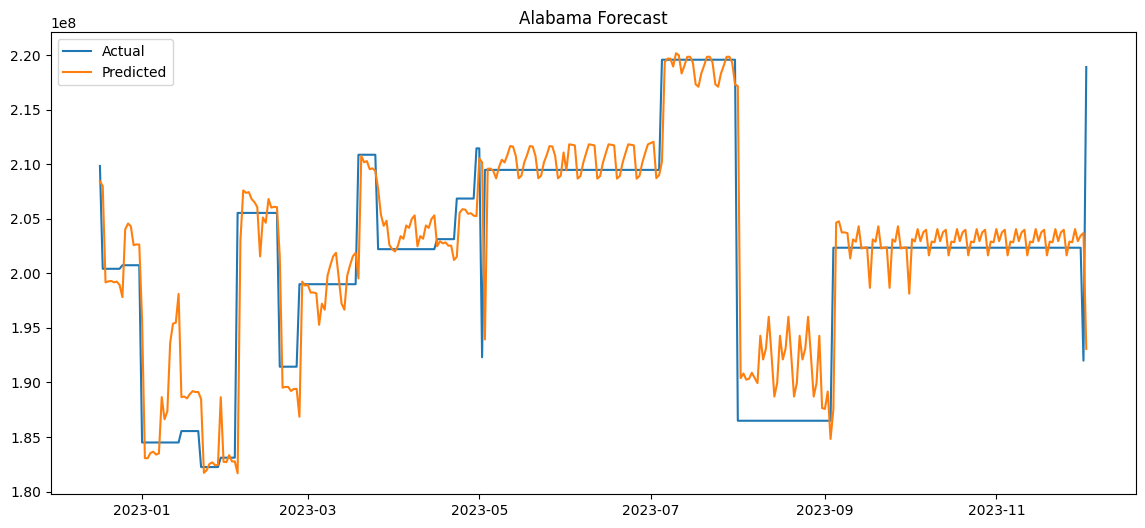

In [54]:
plt.figure(figsize=(14,6))

plt.plot(
    test['date'],
    test['sales'],
    label='Actual'
)

plt.plot(
    test['date'],
    xgb_preds,
    label='Predicted'
)

plt.legend()

plt.title(
    f"{state_name} Forecast"
)

plt.show()

### Future Forecasting

In [55]:
future_steps = 56

future_forecast = []

last_data = data.copy()

for i in range(future_steps):

    row = {}

    row['lag_1'] = last_data['sales'].iloc[-1]

    row['lag_7'] = last_data['sales'].iloc[-7]

    row['lag_30'] = last_data['sales'].iloc[-30]

    row['rolling_mean_7'] = (
        last_data['sales'].iloc[-7:].mean()
    )

    row['rolling_std_7'] = (
        last_data['sales'].iloc[-7:].std()
    )

    next_date = (
        last_data['date'].max()
        + pd.Timedelta(days=1)
    )

    row['day_of_week'] = next_date.dayofweek

    row['month'] = next_date.month

    X_future = pd.DataFrame([row])

    pred = xgb_model.predict(
        X_future
    )[0]

    future_forecast.append(pred)

    temp = pd.DataFrame({
        'date': [next_date],
        'sales': [pred]
    })

    last_data = pd.concat(
        [last_data, temp],
        ignore_index=True
    )

### Plot Future Forecast

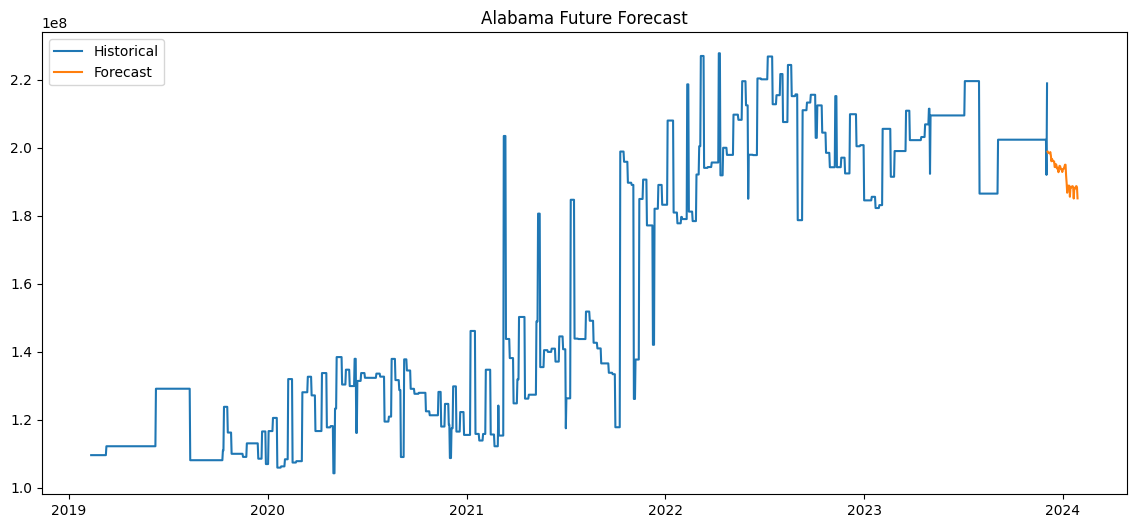

In [56]:
future_dates = pd.date_range(
    start=data['date'].max()
    + pd.Timedelta(days=1),
    periods=future_steps
)

plt.figure(figsize=(14,6))

plt.plot(
    data['date'],
    data['sales'],
    label='Historical'
)

plt.plot(
    future_dates,
    future_forecast,
    label='Forecast'
)

plt.legend()

plt.title(
    f"{state_name} Future Forecast"
)

plt.show()

### State Wise Evaluation

In [57]:
all_states = []

states = state_data['state'].unique()

### Loop All States

In [58]:
for state in states:

    temp = state_data[
        state_data['state'] == state
    ].copy()

    split_index = int(len(temp) * 0.8)

    train_temp = temp.iloc[:split_index]

    test_temp = temp.iloc[split_index:]

    model_temp = XGBRegressor(
        n_estimators=100,
        random_state=42
    )

    model_temp.fit(
        train_temp[features],
        train_temp['sales']
    )

    preds = model_temp.predict(
        test_temp[features]
    )

    mae = mean_absolute_error(
        test_temp['sales'],
        preds
    )

    all_states.append({
        'state': state,
        'mae': mae
    })

### Final State Wise Results

In [61]:
results = pd.DataFrame(all_states)

results.sort_values('mae', ascending=True)

,state,mae
31,Rhode Island,4.529386e+05
37,Vermont,5.328923e+05
42,Wyoming,5.536460e+05
33,South Dakota,6.496353e+05
14,Maine,9.585963e+05
5,Connecticut,1.075755e+06
2,Arkansas,1.654972e+06
21,Nebraska,1.769548e+06
24,New Mexico,1.855335e+06
11,Kansas,1.902424e+06
